# NEXRAD data with Py-ART
 
This notebook provides a workflow for programmatically fetching, parsing, and visualizing 
NEXRAD Level 2 Doppler radar data from the KLOT (Chicago) station using the **Python ARM Radar Toolkit (Py-ART)**.  NEXRAD is a network of 159 high resolution S-band Doppler weather radars.

The default color scales and map extent are set for **clear-air boundary
detection** &mdash; bringing out weak fine lines and convergence zones rather than
storm-scale precipitation &mdash; but every parameter can be changed for general
convective monitoring or other regions.

## Doppler radar background

Weather radar sends out short pulses of microwave radiation and measures the energy scattered back by precipitation, insects, birds, dust, and other targets in the atmosphere. **Reflectivity** measures the strength of the returned signal and is reported in dBZ; large values usually indicate heavier precipitation, while weak values can reveal clear-air features such as insects or fine lines along boundaries. **Radial velocity** uses the Doppler shift of the returned signal to estimate motion toward or away from the radar. It does not measure the full wind vector; it only measures the component of motion along the radar beam. In this notebook, the radar station, date, hour, map extent, sweep angle, and color scales can all be adjusted. The station is set with `RADAR_STATION`, the case time is set with `YEAR`, `MONTH`, `DAY`, and `HOUR`, and the plotted region is controlled by the longitude/latitude bounds in `EXTENT`. The lowest radar tilt is usually best for shallow boundary-layer features such as lake-breeze fronts, but reflectivity and velocity may not be stored in the same sweep index. For example, this case uses sweep 0 for reflectivity and sweep 1 for the lowest usable velocity field. The display ranges, such as `vmin` and `vmax`, can also be changed to emphasize weak clear-air returns, strong precipitation, or subtle velocity shifts.


> Note: `vmin` and `vmax` are matplotlib's color-scale limits — the "v" stands
> for *value*, not velocity. They set the bottom and top of the color bar for
> whatever field is plotted (dBZ for reflectivity, m/s for velocity).


 ## Dependencies and environment setup
 
Ensure you have `pyart`, `boto3` (for pulling from AWS S3 buckets), and `cartopy` 
(for geospatial mapping) installed in your environment.

In [1]:
import datetime
import warnings
from pathlib import Path

import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pyart
from botocore import UNSIGNED
from botocore.config import Config

warnings.filterwarnings('ignore')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



## Parameter configuration
 
 Set your target case date, hour, and the radar station. 
 * **KLOT** is located in Romeoville, IL—ideal for southern Lake Michigan.
 * **KMKX** (Milwaukee) or **KGRB** (Green Bay) are excellent alternatives for northern segments.



In [2]:
# ----- Case event (UTC) -----
YEAR = 2025
MONTH = 5
DAY = 7
HOUR = 21  # ~2:00 PM CDT, prime time for a lake breeze front

# ----- Radar station and map region -----
RADAR_STATION = "KLOT"  # Chicago/Romeoville; alternatives: KMKX (Milwaukee), KGRB (Green Bay)

# Bounding box around southern Lake Michigan / Chicago: [west, east, south, north]
EXTENT = [-89.5, -86.5, 40.5, 43.0]

# ----- Field display settings -----
# Which sweep (tilt) to plot for each field. The lowest tilt (~0.5°) is best
# for shallow boundary-layer features like lake-breeze fronts. Reflectivity and
# velocity are often NOT in the same sweep index — run the sweep-diagnostics
# cell to see which sweeps hold usable data for each field, then set these.
REFLECTIVITY = dict(
    field="reflectivity", sweep=0, cmap="HomeyerRainbow",
    vmin=-5, vmax=25, label="Reflectivity (dBZ)",
)
VELOCITY = dict(
    field="velocity", sweep=1, cmap="NWSVel",
    vmin=-15, vmax=15, label="Radial velocity (m/s)",
)

# ----- Output -----
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Download the radar file

NEXRAD archives every radar scan publicly on Amazon Web Services (AWS) &mdash; a
cloud storage service &mdash; in a "bucket" called `unidata-nexrad-level2`. Files are
named by station and time, so we can construct the path for the exact scan we
want and pull it directly, with no manual searching or browser downloads.

In [3]:
def fetch_nexrad_s3(station, year, month, day, hour):
    """
    Find the first NEXRAD Level II file for a station/hour on the
    public AWS archive and return its S3 path.

    The returned path can be passed directly to
    pyart.io.read_nexrad_archive().
    """
    
    bucket = "unidata-nexrad-level2"
    target_time = datetime.datetime(year, month, day, hour)

    prefix = (
        f"{year:04d}/{month:02d}/{day:02d}/"
        f"{station}/{station}{year:04d}{month:02d}{day:02d}_{hour:02d}"
    )

    print(
        "Searching for NEXRAD Level II files near "
        f"{target_time:%Y-%m-%d %H:%M UTC}..."
    )

    s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

    response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    contents = response.get("Contents", [])

    files = [
        item["Key"]
        for item in contents
        if not item["Key"].endswith("_MDM")
    ]

    if not files:
        raise FileNotFoundError(
            f"No NEXRAD files found for {station} at {target_time:%Y-%m-%d %H UTC}"
        )

    files = sorted(files)
    s3_path = f"s3://{bucket}/{files[0]}"

    print(f"Using file: {s3_path}")

    return s3_path

In [4]:
# Execute the fetch
radar_file = fetch_nexrad_s3(RADAR_STATION, YEAR, MONTH, DAY, HOUR)

Searching for NEXRAD Level II files near 2025-05-07 21:00 UTC...
Using file: s3://unidata-nexrad-level2/2025/05/07/KLOT/KLOT20250507_210436_V06


## Ingest and inspect radar volume via Py-ART
 
 Py-ART parses the complex binary file directly into a `Radar` object. We will inspect the available data fields.

In [ ]:
radar = pyart.io.read_nexrad_archive(radar_file)

In [6]:
print("This radar has:", radar.nsweeps, "sweeps")
print("Elevation (tilt) angle of each sweep, in degrees:")
print(radar.fixed_angle["data"])
print("Available radar fields:")
for field in radar.fields.keys():
    print(f" - {field}")

This radar has: 12 sweeps
Elevation (tilt) angle of each sweep, in degrees:
[0.48339844 0.48339844 0.87890625 0.87890625 1.3183594  1.3183594
 1.8017578  2.4169922  3.1201172  3.9990234  5.0976562  6.4160156 ]
Available radar fields:
 - cross_correlation_ratio
 - velocity
 - differential_phase
 - differential_reflectivity
 - spectrum_width
 - reflectivity
 - clutter_filter_power_removed


In [7]:
print("Sweep diagnostics:")

for sweep in range(radar.nsweeps):
    angle = float(radar.fixed_angle["data"][sweep])

    print(f"\nSweep {sweep}: fixed angle = {angle:.2f} degrees")

    for field in ["reflectivity", "velocity"]:
        if field in radar.fields:
            data = radar.get_field(sweep, field)
            valid_count = np.ma.count(data)

            if valid_count > 0:
                data_min = float(data.min())
                data_max = float(data.max())
                print(
                    f"  {field:12s}: {valid_count:8d} valid gates, "
                    f"range {data_min:7.2f} to {data_max:7.2f}"
                )
            else:
                print(f"  {field:12s}: no valid gates")

Sweep diagnostics:

Sweep 0: fixed angle = 0.48 degrees
  reflectivity:   194724 valid gates, range  -29.50 to   54.00
  velocity    : no valid gates

Sweep 1: fixed angle = 0.48 degrees
  reflectivity:   162944 valid gates, range  -28.00 to   51.50
  velocity    :   112501 valid gates, range  -33.00 to   33.00

Sweep 2: fixed angle = 0.88 degrees
  reflectivity:   184866 valid gates, range  -30.00 to   48.00
  velocity    : no valid gates

Sweep 3: fixed angle = 0.88 degrees
  reflectivity:   154244 valid gates, range  -27.50 to   50.00
  velocity    :   112835 valid gates, range  -33.00 to   33.00

Sweep 4: fixed angle = 1.32 degrees
  reflectivity:   161983 valid gates, range  -30.00 to   42.50
  velocity    : no valid gates

Sweep 5: fixed angle = 1.32 degrees
  reflectivity:   136717 valid gates, range  -29.00 to   43.00
  velocity    :   105095 valid gates, range  -33.00 to   33.00

Sweep 6: fixed angle = 1.80 degrees
  reflectivity:    38499 valid gates, range  -28.00 to   42.00

## Plot reflectivity and velocity

Two side-by-side maps: reflectivity (how much energy returns) and radial
velocity (motion toward or away from the radar).

The reflectivity color scale is deliberately set low (see the `REFLECTIVITY`
settings above). Clear-air boundaries show up as weak returns from insects and
dust caught in the convergence zone — these would vanish under a storm-scale
range, where they'd register as near-zero against heavy precipitation.

Reflectivity and velocity are drawn from different sweeps because, at the lowest
tilt, the radar scans twice — once tuned for each field (see the sweep
diagnostics for which index holds usable data).

Saved figure to figures/radar_KLOT_20250507_21UTC.png


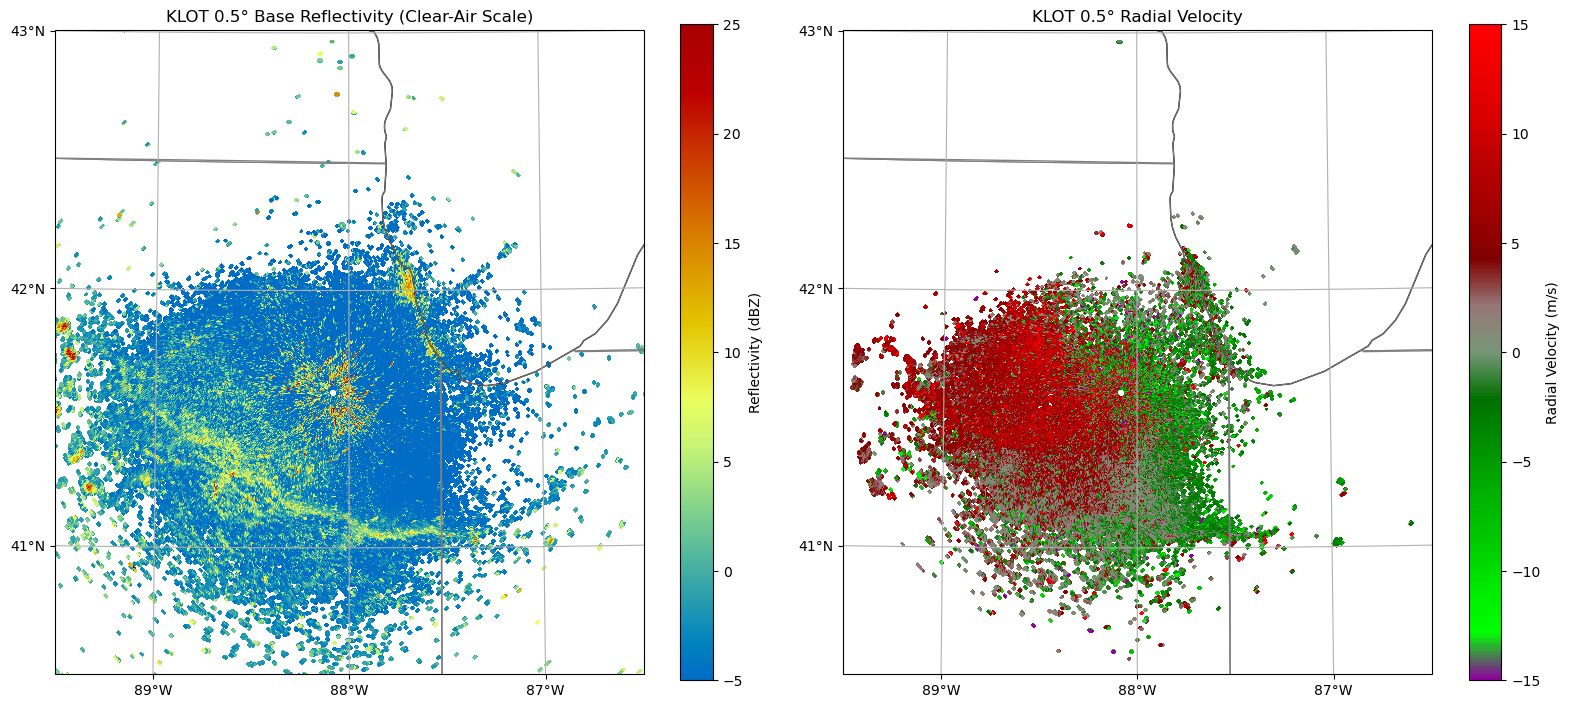

In [8]:
# Initialize Py-ART's specialized RadarMapDisplay object
display = pyart.graph.RadarMapDisplay(radar)

# Set up a Cartopy map projection centered on the radar site
projection = ccrs.LambertConformal(
    central_longitude=radar.longitude['data'][0],
    central_latitude=radar.latitude['data'][0]
)

fig = plt.figure(figsize=(16, 7))

# --- Panel 1: Reflectivity (Fine Line Target) ---
ax1 = fig.add_subplot(1, 2, 1, projection=projection)
display.plot_ppi_map(
    REFLECTIVITY["field"], 
    sweep=REFLECTIVITY["sweep"],                  # Lowest tilt angle (0.5 degrees)
    vmin=REFLECTIVITY["vmin"], 
    vmax=REFLECTIVITY["vmax"],     # Clean scale tailored to capture clear-air biological return
    cmap=REFLECTIVITY["cmap"],
    ax=ax1, 
    min_lon=EXTENT[0], max_lon=EXTENT[1], 
    min_lat=EXTENT[2], max_lat=EXTENT[3],
    title=f"{RADAR_STATION} 0.5° Base Reflectivity (Clear-Air Scale)",
    colorbar_label="Reflectivity (dBZ)"
)
# Add map detailing features
ax1.add_feature(cfeature.LAKES, edgecolor="black", facecolor="none", linewidth=1.0)
ax1.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.7)
ax1.add_feature(cfeature.BORDERS, edgecolor="gray", linewidth=0.7)

# --- Panel 2: Radial Velocity (Wind Discontinuity Target) ---
ax2 = fig.add_subplot(1, 2, 2, projection=projection)
display.plot_ppi_map(
    VELOCITY["field"], 
    sweep=VELOCITY["sweep"], 
    vmin=VELOCITY["vmin"], 
    vmax=VELOCITY["vmax"],    # Focus on localized shifts in m/s
    cmap=VELOCITY["cmap"],
    ax=ax2, 
    min_lon=EXTENT[0], max_lon=EXTENT[1], 
    min_lat=EXTENT[2], max_lat=EXTENT[3],
    title=f"{RADAR_STATION} 0.5° Radial Velocity",
    colorbar_label="Radial Velocity (m/s)"
)

ax2.add_feature(cfeature.LAKES, edgecolor="black", facecolor="none", linewidth=1.0)
ax2.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.7)
ax2.add_feature(cfeature.BORDERS, edgecolor="gray", linewidth=0.7)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / f"radar_{RADAR_STATION}_{YEAR:04d}"
    f"{MONTH:02d}{DAY:02d}_{HOUR:02d}UTC.png"
)

fig.savefig(figure_path, dpi=200, bbox_inches="tight")

print(f"Saved figure to {figure_path}")

plt.show()

**Reading the velocity panel.** Radial velocity is not the wind direction &mdash;
it is only the part of the motion aimed *along the radar beam*, toward or away
from the radar. By convention, motion **away** from the radar is positive
(warm colors) and motion **toward** it is negative (cool colors). Wind blowing
*across* the beam, perpendicular to it, registers as zero no matter how strong &mdash;
so a band of "zero" velocity does not mean calm air, just air moving crosswise
to the beam. What this panel reveals well is a *boundary*: a sharp change in
color marks where the flow shifts, such as cool marine air pushing against the
regional wind along a lake-breeze front.

## Analyzing the output
 
When a lake breeze event is occurring on the plots above, look for these two coupled signatures:
 
1. **The Reflectivity Fine Line:** Look closely at the land-water boundary on Panel 1. If a lake breeze has pushed inland, you will see a thin, distinct, linear ribbon of low reflectivity (`5 to 15 dBZ`) tracking parallel to the coast. This is insects and dust caught in the convergence zone.
2. **Velocity Boundary Layer Clash:** On Panel 2, check the radial velocity along that exact fine-line location. You should see a sharp, sudden change in color values representing the onshore flow of the cool marine layer overriding or pushing against the regional wind vectors.